# Multiclass Dataset Statistics

This notebook provides comprehensive statistics and visualizations for the multiclass counting benchmark dataset.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
import os

# Create stats directory for outputs
os.makedirs('stats', exist_ok=True)

# Set plot style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Load Dataset Files

In [2]:
# Load all JSON files
with open('annotations.json', 'r') as f:
    annotations = json.load(f)

with open('class_mapping.json', 'r') as f:
    class_mapping = json.load(f)

with open('multiclass_gt_counts.json', 'r') as f:
    gt_counts = json.load(f)

with open('multiclass_class_counts_per_image.json', 'r') as f:
    class_counts_per_image = json.load(f)

with open('multiclass_split_images.json', 'r') as f:
    split_images = json.load(f)

with open('multiclass_split_classes.json', 'r') as f:
    split_classes = json.load(f)

print("✓ All dataset files loaded successfully")

✓ All dataset files loaded successfully


## Basic Dataset Statistics

In [3]:
# Total images
total_images = len(gt_counts)

# Total classes
total_classes = len(class_mapping)
class_names = list(class_mapping.values())

# Total objects across all images
total_objects = sum(gt_counts.values())

# Average count per image
avg_count_per_image = total_objects / total_images

print("="*60)
print("MULTICLASS COUNTING DATASET STATISTICS")
print("="*60)
print(f"\nTotal Images: {total_images}")
print(f"Total Classes: {total_classes}")
print(f"Total Object Instances: {total_objects:,}")
print(f"\nAverage Objects per Image: {avg_count_per_image:.2f}")
print(f"Min Objects per Image: {min(gt_counts.values())}")
print(f"Max Objects per Image: {max(gt_counts.values())}")
print(f"Median Objects per Image: {np.median(list(gt_counts.values())):.2f}")
print("="*60)

MULTICLASS COUNTING DATASET STATISTICS

Total Images: 200
Total Classes: 45
Total Object Instances: 12,265

Average Objects per Image: 61.33
Min Objects per Image: 3
Max Objects per Image: 1110
Median Objects per Image: 26.50


## Classes per Image Statistics

In [4]:
# Calculate number of classes per image
classes_per_image = []
for img_name, class_counts in class_counts_per_image.items():
    num_classes = sum(1 for count in class_counts.values() if count > 0)
    classes_per_image.append(num_classes)

avg_classes_per_image = np.mean(classes_per_image)
median_classes_per_image = np.median(classes_per_image)
min_classes = min(classes_per_image)
max_classes = max(classes_per_image)

print("Classes per Image Statistics:")
print(f"  Average: {avg_classes_per_image:.2f}")
print(f"  Median: {median_classes_per_image:.0f}")
print(f"  Min: {min_classes}")
print(f"  Max: {max_classes}")
print(f"  Std Dev: {np.std(classes_per_image):.2f}")

# Distribution of classes per image
classes_distribution = Counter(classes_per_image)
print(f"\nDistribution of number of classes per image:")
for num_classes in sorted(classes_distribution.keys()):
    count = classes_distribution[num_classes]
    percentage = (count / len(classes_per_image)) * 100
    print(f"  {num_classes} classes: {count} images ({percentage:.1f}%)")

Classes per Image Statistics:
  Average: 2.55
  Median: 2
  Min: 2
  Max: 7
  Std Dev: 0.87

Distribution of number of classes per image:
  2 classes: 126 images (63.0%)
  3 classes: 49 images (24.5%)
  4 classes: 17 images (8.5%)
  5 classes: 6 images (3.0%)
  6 classes: 1 images (0.5%)
  7 classes: 1 images (0.5%)


## Per-Class Statistics

In [5]:
# Calculate statistics per class
class_stats = defaultdict(lambda: {'total_instances': 0, 'num_images': 0, 'counts': []})

for img_name, class_counts in class_counts_per_image.items():
    for class_name, count in class_counts.items():
        if count > 0:
            class_stats[class_name]['total_instances'] += count
            class_stats[class_name]['num_images'] += 1
            class_stats[class_name]['counts'].append(count)

# Create a DataFrame for easier analysis
class_stats_list = []
for class_name in class_names:
    stats = class_stats[class_name]
    if stats['num_images'] > 0:
        avg_count = stats['total_instances'] / stats['num_images']
        class_stats_list.append({
            'Class': class_name,
            'Total Instances': stats['total_instances'],
            'Num Images': stats['num_images'],
            'Avg per Image': avg_count,
            'Min': min(stats['counts']),
            'Max': max(stats['counts']),
            'Std Dev': np.std(stats['counts'])
        })
    else:
        class_stats_list.append({
            'Class': class_name,
            'Total Instances': 0,
            'Num Images': 0,
            'Avg per Image': 0,
            'Min': 0,
            'Max': 0,
            'Std Dev': 0
        })

df_class_stats = pd.DataFrame(class_stats_list)
df_class_stats = df_class_stats.sort_values('Total Instances', ascending=False)

print("\nPer-Class Statistics (sorted by total instances):")
print(df_class_stats.to_string(index=False))

# Average objects per class
avg_instances_per_class = df_class_stats['Total Instances'].mean()
print(f"\nAverage instances per class: {avg_instances_per_class:.2f}")


Per-Class Statistics (sorted by total instances):
          Class  Total Instances  Num Images  Avg per Image  Min  Max    Std Dev
         people             3756          60      62.600000    1  679 114.898390
           cars              959          40      23.975000    1  113  25.404220
       cherries              938           6     156.333333    2  759 272.640586
beach umbrellas              675          10      67.500000    4  239  71.957279
    blueberries              627          14      44.785714    3  128  39.706384
     motorbikes              472          25      18.880000    1   64  19.920482
   strawberries              386           8      48.250000    2  326 105.226838
        windows              353          11      32.090909    9   72  17.748007
        guitars              323          16      20.187500    1  121  28.851384
         chairs              314          15      20.933333    1   61  17.755625
   red currants              301           6      50.16666

## Class Co-occurrence Analysis

In [6]:
# Analyze which classes appear together frequently
class_pairs = defaultdict(int)

for img_name, class_counts in class_counts_per_image.items():
    present_classes = [cls for cls, count in class_counts.items() if count > 0]
    
    # Count co-occurrences
    for i, cls1 in enumerate(present_classes):
        for cls2 in present_classes[i+1:]:
            pair = tuple(sorted([cls1, cls2]))
            class_pairs[pair] += 1

# Get top 15 co-occurring class pairs
top_pairs = sorted(class_pairs.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top 15 Co-occurring Class Pairs:")
for (cls1, cls2), count in top_pairs:
    percentage = (count / total_images) * 100
    print(f"  {cls1} + {cls2}: {count} images ({percentage:.1f}%)")

Top 15 Co-occurring Class Pairs:
  cars + people: 26 images (13.0%)
  motorbikes + people: 24 images (12.0%)
  cars + trucks: 16 images (8.0%)
  cars + motorbikes: 15 images (7.5%)
  blueberries + raspberries: 13 images (6.5%)
  blackberries + raspberries: 13 images (6.5%)
  blackberries + blueberries: 13 images (6.5%)
  amplifiers + guitars: 13 images (6.5%)
  forks + knives: 11 images (5.5%)
  balconies + windows: 11 images (5.5%)
  apples + pears: 10 images (5.0%)
  beach umbrellas + people: 10 images (5.0%)
  keys + padlocks: 10 images (5.0%)
  bowls + plates: 9 images (4.5%)
  cups + plates: 9 images (4.5%)


## Visualization: Distribution of Objects per Image

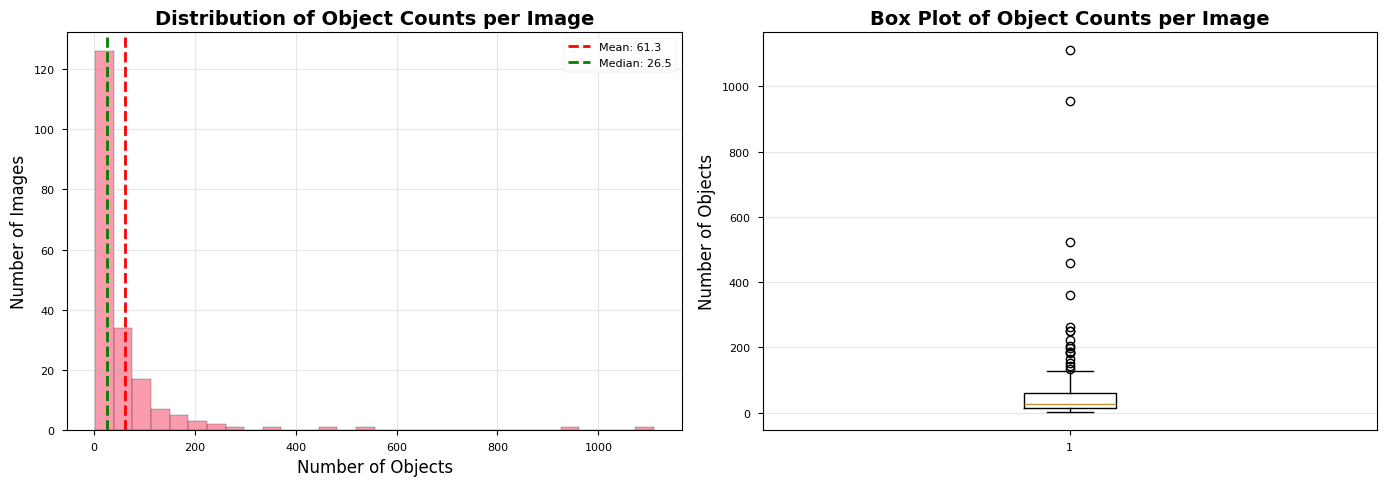

Saved figure: stats/object_distribution.pdf


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
counts = list(gt_counts.values())
axes[0].hist(counts, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(avg_count_per_image, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_count_per_image:.1f}')
axes[0].axvline(np.median(counts), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(counts):.1f}')
axes[0].set_xlabel('Number of Objects', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Distribution of Object Counts per Image', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(counts, vert=True)
axes[1].set_ylabel('Number of Objects', fontsize=12)
axes[1].set_title('Box Plot of Object Counts per Image', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('stats/object_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/object_distribution.pdf")

## Visualization: Distribution of Classes per Image

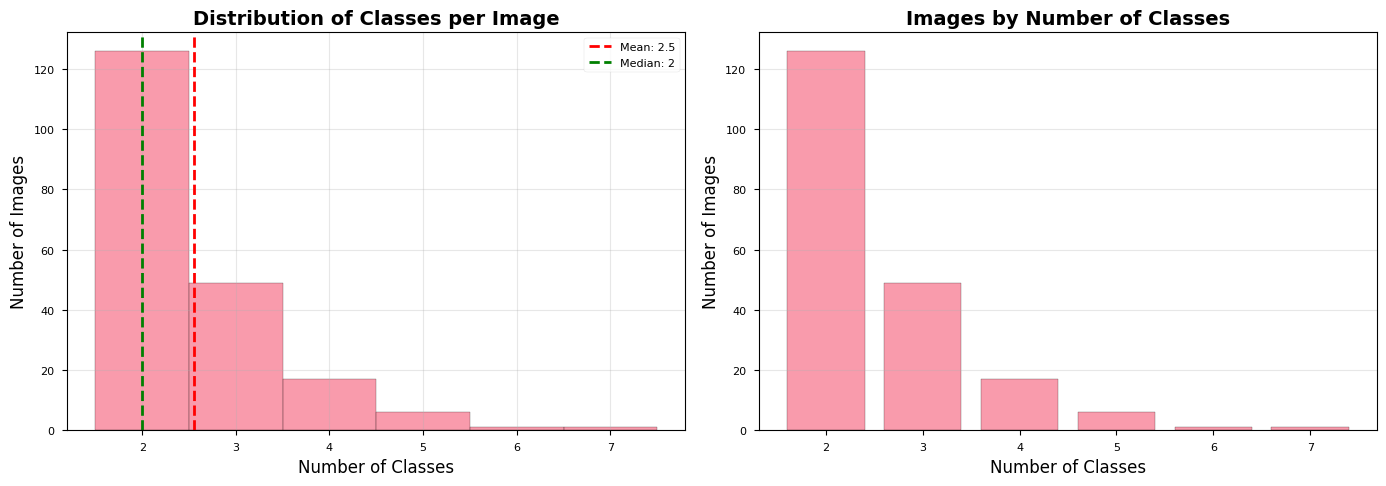

Saved figure: stats/classes_per_image_distribution.pdf


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(classes_per_image, bins=range(min_classes, max_classes+2), edgecolor='black', alpha=0.7, align='left')
axes[0].axvline(avg_classes_per_image, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_classes_per_image:.1f}')
axes[0].axvline(median_classes_per_image, color='green', linestyle='--', linewidth=2, label=f'Median: {median_classes_per_image:.0f}')
axes[0].set_xlabel('Number of Classes', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Distribution of Classes per Image', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(min_classes, max_classes+1))

# Bar chart
classes_dist = sorted(classes_distribution.items())
x_vals = [x[0] for x in classes_dist]
y_vals = [x[1] for x in classes_dist]
axes[1].bar(x_vals, y_vals, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Classes', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Images by Number of Classes', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(x_vals)

plt.tight_layout()
plt.savefig('stats/classes_per_image_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/classes_per_image_distribution.pdf")

## Visualization: Top Classes by Instance Count

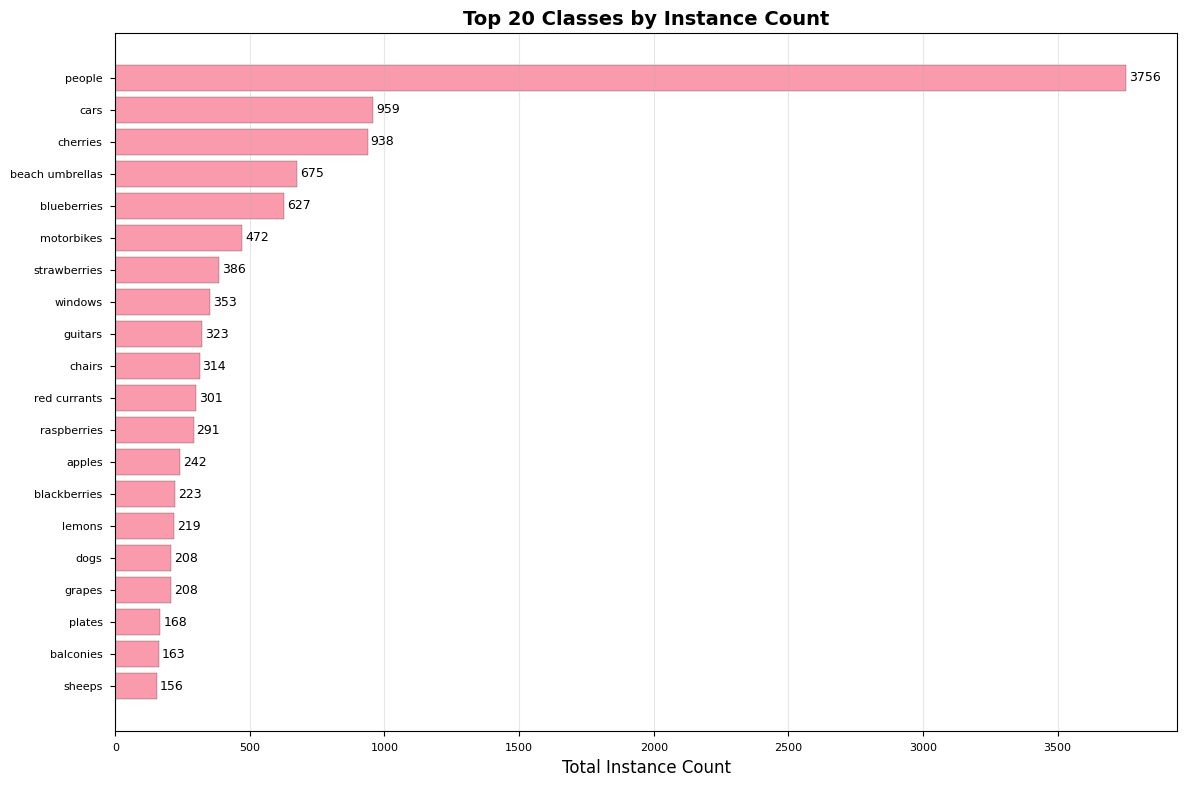

Saved figure: stats/top_classes_by_instances.pdf


In [9]:
# Top 20 classes by total instances
top_n = 20
df_top = df_class_stats.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(df_top)), df_top['Total Instances'], edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(df_top)))
ax.set_yticklabels(df_top['Class'])
ax.set_xlabel('Total Instance Count', fontsize=12)
ax.set_title(f'Top {top_n} Classes by Instance Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, row) in enumerate(df_top.iterrows()):
    ax.text(row['Total Instances'] + 10, i, f"{int(row['Total Instances'])}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('stats/top_classes_by_instances.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/top_classes_by_instances.pdf")

## Visualization: Classes by Image Frequency

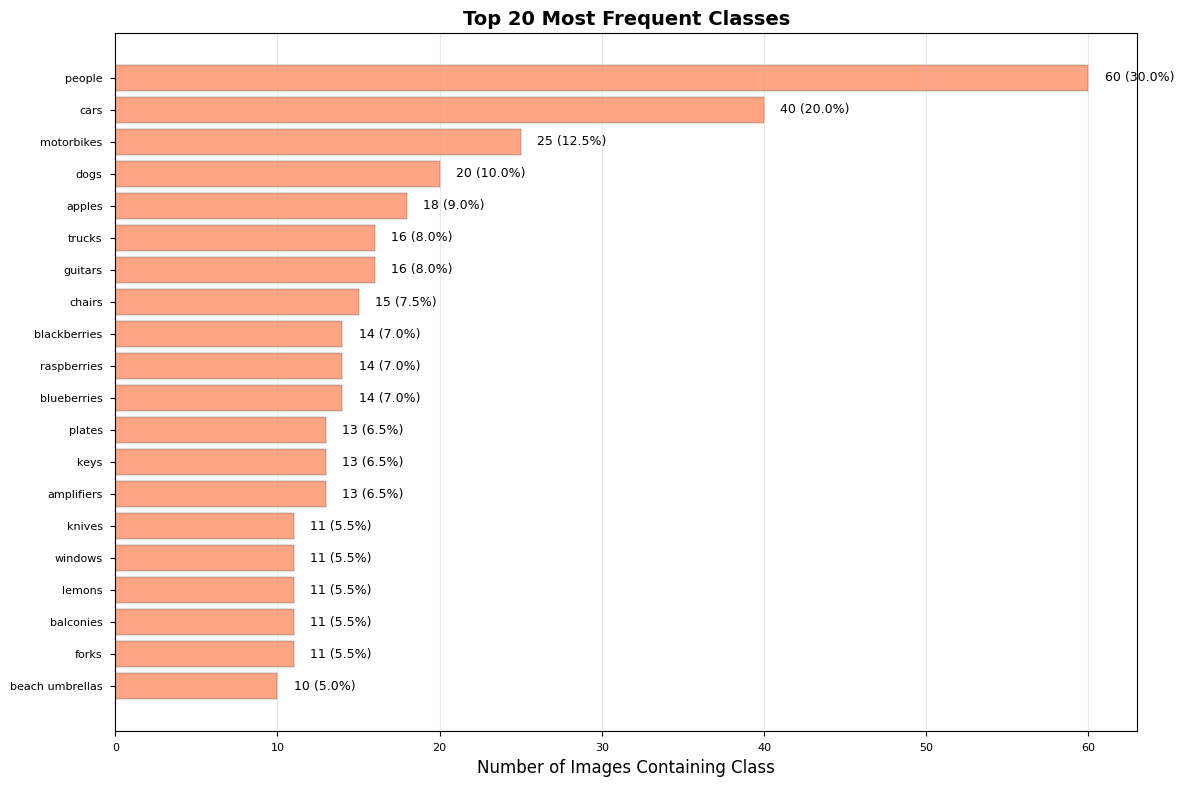

Saved figure: stats/top_classes_by_frequency.pdf


In [10]:
# Sort by number of images containing each class
df_by_images = df_class_stats.sort_values('Num Images', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(df_by_images)), df_by_images['Num Images'], edgecolor='black', alpha=0.7, color='coral')
ax.set_yticks(range(len(df_by_images)))
ax.set_yticklabels(df_by_images['Class'])
ax.set_xlabel('Number of Images Containing Class', fontsize=12)
ax.set_title(f'Top {top_n} Most Frequent Classes', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels and percentages
for i, (idx, row) in enumerate(df_by_images.iterrows()):
    percentage = (row['Num Images'] / total_images) * 100
    ax.text(row['Num Images'] + 1, i, f"{int(row['Num Images'])} ({percentage:.1f}%)", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('stats/top_classes_by_frequency.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/top_classes_by_frequency.pdf")

## Visualization: Average Count per Class (when present)

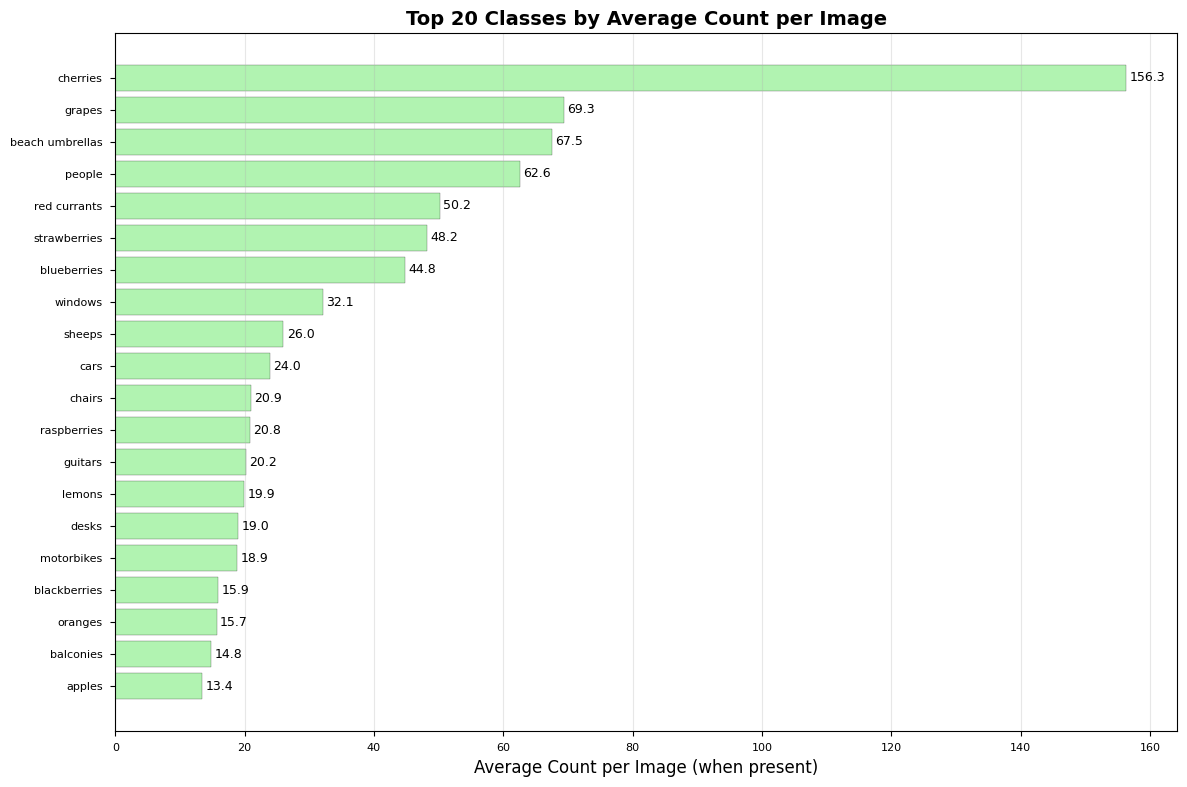

Saved figure: stats/top_classes_by_avg_count.pdf


In [11]:
# Classes with highest average count when present
df_by_avg = df_class_stats[df_class_stats['Num Images'] > 0].sort_values('Avg per Image', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(df_by_avg)), df_by_avg['Avg per Image'], edgecolor='black', alpha=0.7, color='lightgreen')
ax.set_yticks(range(len(df_by_avg)))
ax.set_yticklabels(df_by_avg['Class'])
ax.set_xlabel('Average Count per Image (when present)', fontsize=12)
ax.set_title(f'Top {top_n} Classes by Average Count per Image', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(df_by_avg.iterrows()):
    ax.text(row['Avg per Image'] + 0.5, i, f"{row['Avg per Image']:.1f}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('stats/top_classes_by_avg_count.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/top_classes_by_avg_count.pdf")

## Summary Statistics Table for Paper

In [12]:
# Create a comprehensive summary table
summary_data = {
    'Metric': [
        'Total Images',
        'Total Classes',
        'Total Object Instances',
        'Avg Objects per Image',
        'Median Objects per Image',
        'Min Objects per Image',
        'Max Objects per Image',
        'Avg Classes per Image',
        'Median Classes per Image',
        'Min Classes per Image',
        'Max Classes per Image',
        'Avg Instances per Class',
    ],
    'Value': [
        total_images,
        total_classes,
        f"{total_objects:,}",
        f"{avg_count_per_image:.2f}",
        f"{np.median(list(gt_counts.values())):.0f}",
        min(gt_counts.values()),
        max(gt_counts.values()),
        f"{avg_classes_per_image:.2f}",
        f"{median_classes_per_image:.0f}",
        min_classes,
        max_classes,
        f"{avg_instances_per_class:.2f}",
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("SUMMARY STATISTICS TABLE FOR PAPER")
print("="*60)
print(df_summary.to_string(index=False))
print("="*60)

# Save to CSV
df_summary.to_csv('stats/dataset_summary_statistics.csv', index=False)
print("\nSaved: stats/dataset_summary_statistics.csv")

# Save detailed class statistics
df_class_stats.to_csv('stats/class_statistics.csv', index=False)
print("Saved: stats/class_statistics.csv")


SUMMARY STATISTICS TABLE FOR PAPER
                  Metric  Value
            Total Images    200
           Total Classes     45
  Total Object Instances 12,265
   Avg Objects per Image  61.33
Median Objects per Image     26
   Min Objects per Image      3
   Max Objects per Image   1110
   Avg Classes per Image   2.55
Median Classes per Image      2
   Min Classes per Image      2
   Max Classes per Image      7
 Avg Instances per Class 272.56

Saved: stats/dataset_summary_statistics.csv
Saved: stats/class_statistics.csv


## Class Distribution Across Difficulty Levels


Image Distribution by Difficulty:
  Easy (0-20 objects): 87 images (43.5%)
  Medium (21-50 objects): 57 images (28.5%)
  Hard (51-100 objects): 24 images (12.0%)
  Very Hard (>100 objects): 32 images (16.0%)


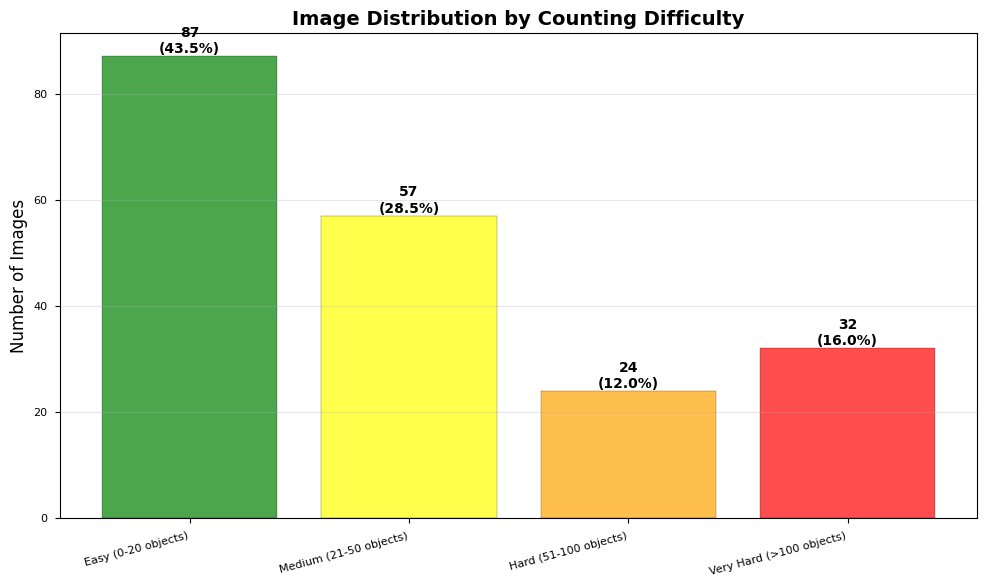

Saved figure: stats/difficulty_distribution.pdf


In [13]:
# Categorize images by difficulty based on object count
difficulty_bins = [(0, 20, 'Easy (0-20 objects)'), 
                   (21, 50, 'Medium (21-50 objects)'), 
                   (51, 100, 'Hard (51-100 objects)'),
                   (101, float('inf'), 'Very Hard (>100 objects)')]

difficulty_counts = {label: 0 for _, _, label in difficulty_bins}

for img_name, count in gt_counts.items():
    for min_val, max_val, label in difficulty_bins:
        if min_val <= count <= max_val:
            difficulty_counts[label] += 1
            break

print("\nImage Distribution by Difficulty:")
for label, count in difficulty_counts.items():
    percentage = (count / total_images) * 100
    print(f"  {label}: {count} images ({percentage:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
labels = list(difficulty_counts.keys())
values = list(difficulty_counts.values())
bars = ax.bar(labels, values, edgecolor='black', alpha=0.7, color=['green', 'yellow', 'orange', 'red'])

ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Distribution by Counting Difficulty', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}\n({val/total_images*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('stats/difficulty_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/difficulty_distribution.pdf")

## Additional Statistics: Image Resolution Analysis


Image Resolution Statistics:
  Width  - Mean: 1021, Min: 225, Max: 4000
  Height - Mean: 774, Min: 181, Max: 4000
  Aspect Ratio - Mean: 1.39, Min: 0.57, Max: 2.70


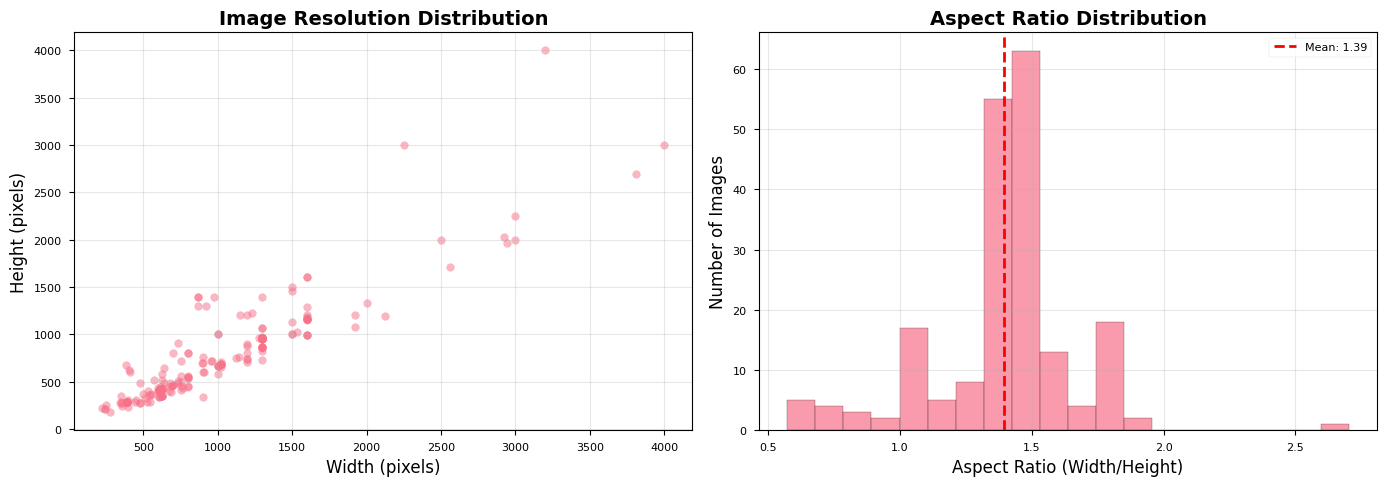

Saved figure: stats/resolution_analysis.pdf


In [14]:
# Analyze image resolutions
resolutions = []
aspect_ratios = []

for img_name, annotation in annotations.items():
    if 'H' in annotation and 'W' in annotation:
        height = annotation['H']
        width = annotation['W']
        resolutions.append((width, height))
        aspect_ratios.append(width / height)

if resolutions:
    widths = [r[0] for r in resolutions]
    heights = [r[1] for r in resolutions]
    
    print("\nImage Resolution Statistics:")
    print(f"  Width  - Mean: {np.mean(widths):.0f}, Min: {min(widths)}, Max: {max(widths)}")
    print(f"  Height - Mean: {np.mean(heights):.0f}, Min: {min(heights)}, Max: {max(heights)}")
    print(f"  Aspect Ratio - Mean: {np.mean(aspect_ratios):.2f}, Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot of resolutions
    axes[0].scatter(widths, heights, alpha=0.5)
    axes[0].set_xlabel('Width (pixels)', fontsize=12)
    axes[0].set_ylabel('Height (pixels)', fontsize=12)
    axes[0].set_title('Image Resolution Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Aspect ratio histogram
    axes[1].hist(aspect_ratios, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(aspect_ratios), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(aspect_ratios):.2f}')
    axes[1].set_xlabel('Aspect Ratio (Width/Height)', fontsize=12)
    axes[1].set_ylabel('Number of Images', fontsize=12)
    axes[1].set_title('Aspect Ratio Distribution', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('stats/resolution_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved figure: stats/resolution_analysis.pdf")

## Export LaTeX Table for Paper

In [15]:
# Create a LaTeX-formatted table
latex_table = r"""
\begin{table}[h]
\centering
\caption{Multiclass Counting Dataset Statistics}
\label{tab:dataset_stats}
\begin{tabular}{lr}
\toprule
\textbf{Metric} & \textbf{Value} \\
\midrule
"""

for _, row in df_summary.iterrows():
    latex_table += f"{row['Metric']} & {row['Value']} \\\\ \
        "

latex_table += r"""
\bottomrule
\end{tabular}
\end{table}
"""

with open('stats/dataset_statistics_latex.tex', 'w') as f:
    f.write(latex_table)

print("\nLaTeX table saved to: stats/dataset_statistics_latex.tex")
print("\nLaTeX Table Preview:")
print(latex_table)


LaTeX table saved to: stats/dataset_statistics_latex.tex

LaTeX Table Preview:

\begin{table}[h]
\centering
\caption{Multiclass Counting Dataset Statistics}
\label{tab:dataset_stats}
\begin{tabular}{lr}
\toprule
\textbf{Metric} & \textbf{Value} \\
\midrule
Total Images & 200 \\         Total Classes & 45 \\         Total Object Instances & 12,265 \\         Avg Objects per Image & 61.33 \\         Median Objects per Image & 26 \\         Min Objects per Image & 3 \\         Max Objects per Image & 1110 \\         Avg Classes per Image & 2.55 \\         Median Classes per Image & 2 \\         Min Classes per Image & 2 \\         Max Classes per Image & 7 \\         Avg Instances per Class & 272.56 \\         
\bottomrule
\end{tabular}
\end{table}



## Publication-Quality 4-Panel Figure

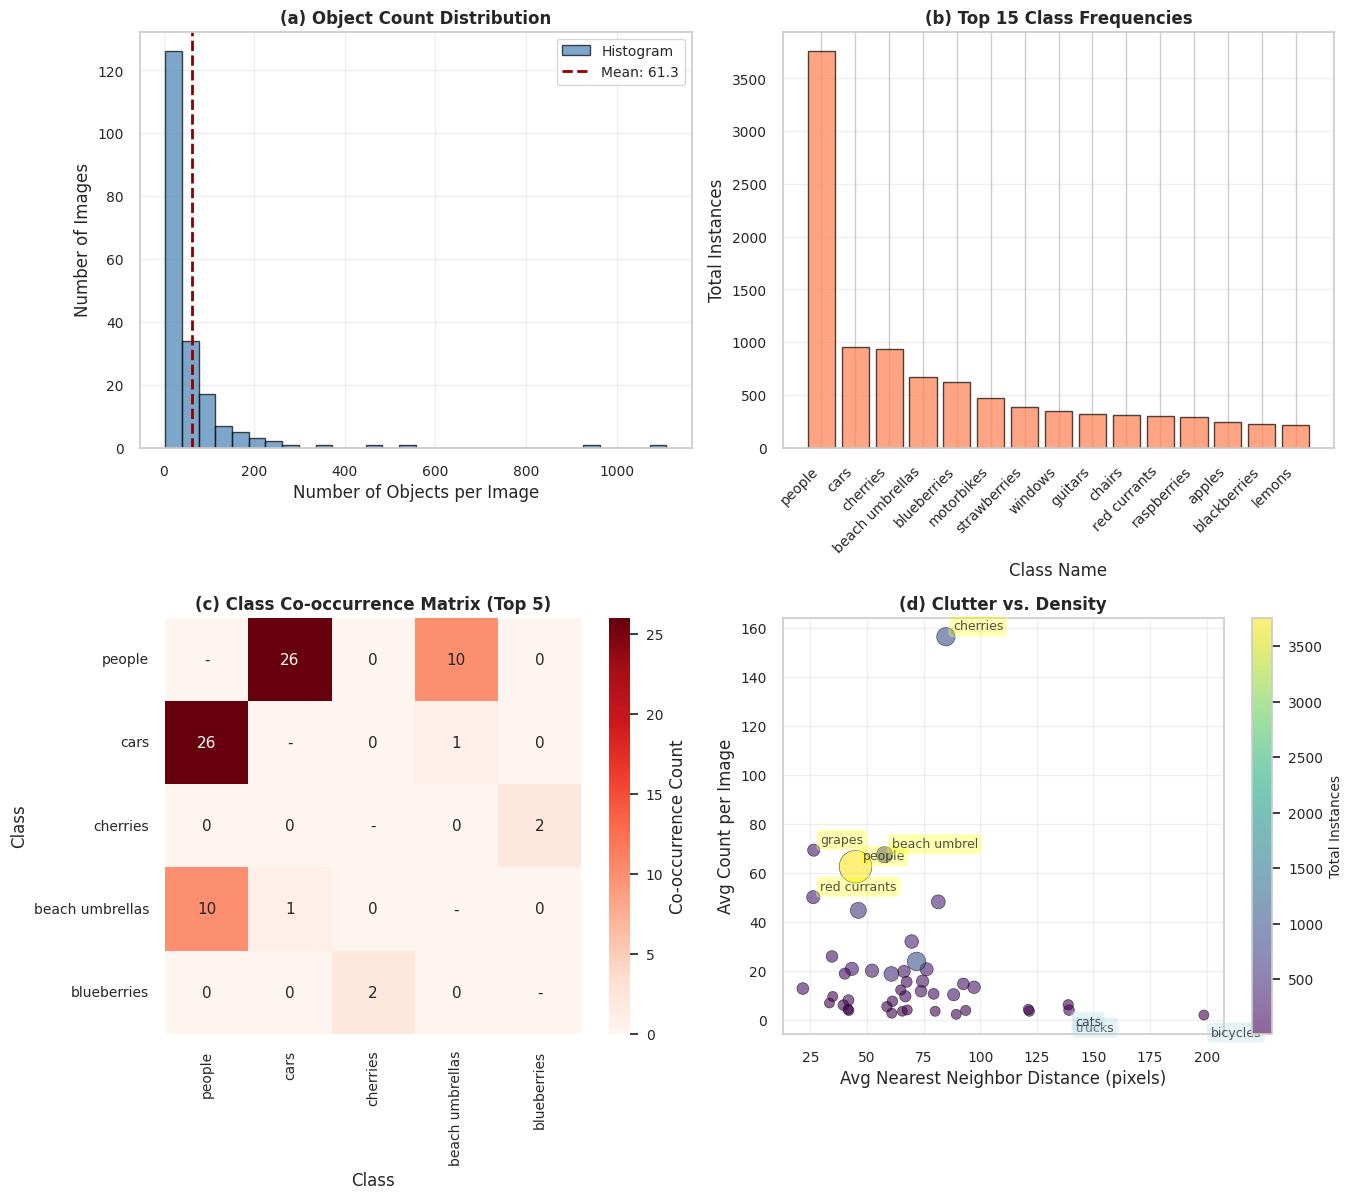

Saved: stats/dataset_stats_4panel.pdf

Panel (d) includes 45 classes with sufficient point data for NND calculation.


In [16]:
from scipy.spatial import KDTree
from scipy.stats import gaussian_kde

# Set publication-quality style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ========== Panel (a): Object Count Distribution ==========
ax_a = axes[0, 0]
counts = list(gt_counts.values())
n, bins, patches = ax_a.hist(counts, bins=30, edgecolor='black', alpha=0.7, 
                               color='steelblue', label='Histogram')

# Add mean line
mean_count = np.mean(counts)
ax_a.axvline(mean_count, color='darkred', linestyle='--', linewidth=2, 
             label=f'Mean: {mean_count:.1f}')

ax_a.set_xlabel('Number of Objects per Image', fontsize=12)
ax_a.set_ylabel('Number of Images', fontsize=12)
ax_a.set_title('(a) Object Count Distribution', fontsize=12, fontweight='bold')
ax_a.legend(loc='upper right', fontsize=10)
ax_a.grid(True, alpha=0.3)

# ========== Panel (b): Class Frequency ==========
ax_b = axes[0, 1]
df_top15 = df_class_stats.nlargest(15, 'Total Instances')
bars = ax_b.bar(range(len(df_top15)), df_top15['Total Instances'], 
                edgecolor='black', alpha=0.7, color='coral')
ax_b.set_xticks(range(len(df_top15)))
ax_b.set_xticklabels(df_top15['Class'], rotation=45, ha='right', fontsize=10)
ax_b.set_xlabel('Class Name', fontsize=12)
ax_b.set_ylabel('Total Instances', fontsize=12)
ax_b.set_title('(b) Top 15 Class Frequencies', fontsize=12, fontweight='bold')
ax_b.grid(True, alpha=0.3, axis='y')

# ========== Panel (c): Class Co-occurrence Heatmap ==========
ax_c = axes[1, 0]

# Get top 5 classes by frequency
top5_classes = df_class_stats.nlargest(5, 'Total Instances')['Class'].tolist()

# Create co-occurrence matrix
cooccur_matrix = np.zeros((len(top5_classes), len(top5_classes)))

for img_name, class_counts in class_counts_per_image.items():
    present_classes = [cls for cls, count in class_counts.items() if count > 0 and cls in top5_classes]
    
    for i, cls1 in enumerate(top5_classes):
        for j, cls2 in enumerate(top5_classes):
            if cls1 in present_classes and cls2 in present_classes:
                cooccur_matrix[i, j] += 1

# Set diagonal to zero (skip self co-occurrence)
for i in range(len(top5_classes)):
    cooccur_matrix[i, i] = 0

# Create custom annotations with '-' on diagonal
annot_matrix = []
for i in range(len(top5_classes)):
    row = []
    for j in range(len(top5_classes)):
        if i == j:
            row.append('-')
        else:
            row.append(str(int(cooccur_matrix[i, j])))
    annot_matrix.append(row)

# Plot heatmap with absolute co-occurrence counts
sns.heatmap(cooccur_matrix, annot=annot_matrix, fmt='', cmap='Reds', 
            xticklabels=[c[:20] for c in top5_classes], 
            yticklabels=[c[:20] for c in top5_classes],
            cbar_kws={'label': 'Co-occurrence Count'}, ax=ax_c, 
            square=True)
ax_c.set_title('(c) Class Co-occurrence Matrix (Top 5)', fontsize=12, fontweight='bold')
ax_c.set_xlabel('Class', fontsize=12)
ax_c.set_ylabel('Class', fontsize=12)

# ========== Panel (d): Clutter vs. Density Scatter Plot ==========
ax_d = axes[1, 1]

# Calculate average nearest neighbor distance per class
class_nnd_data = defaultdict(lambda: {'nnds': [], 'counts': [], 'total_instances': 0, 'num_images': 0})

# Build mapping from class index to class name
idx_to_class = {int(k): v for k, v in class_mapping.items()}

for img_name, annotation in annotations.items():
    if 'points' not in annotation or 'classes' not in annotation:
        continue
    
    points = np.array(annotation['points'])
    class_labels = annotation['classes']
    
    if len(points) == 0 or len(class_labels) == 0:
        continue
    
    # Group points by class
    class_points = defaultdict(list)
    for point, cls_idx in zip(points, class_labels):
        class_name = idx_to_class.get(cls_idx)
        if class_name:
            class_points[class_name].append(point)
    
    # Calculate NND for each class in this image
    for class_name, pts in class_points.items():
        pts_array = np.array(pts)
        count = len(pts_array)
        
        if count >= 2:  # Need at least 2 points to calculate NND
            # Build KDTree and find nearest neighbors
            tree = KDTree(pts_array)
            distances, indices = tree.query(pts_array, k=2)  # k=2 to get self and nearest neighbor
            # distances[:, 1] contains distances to nearest neighbor (excluding self)
            avg_nnd = np.mean(distances[:, 1])
            class_nnd_data[class_name]['nnds'].append(avg_nnd)
        
        class_nnd_data[class_name]['counts'].append(count)
        class_nnd_data[class_name]['total_instances'] += count
        class_nnd_data[class_name]['num_images'] += 1

# Prepare data for scatter plot
scatter_data = []
for class_name in class_names:
    if class_name in class_nnd_data and len(class_nnd_data[class_name]['nnds']) > 0:
        avg_nnd = np.mean(class_nnd_data[class_name]['nnds'])
        avg_count = np.mean(class_nnd_data[class_name]['counts'])
        total_inst = class_nnd_data[class_name]['total_instances']
        scatter_data.append({
            'class': class_name,
            'avg_nnd': avg_nnd,
            'avg_count': avg_count,
            'total_instances': total_inst
        })

if scatter_data:
    df_scatter = pd.DataFrame(scatter_data)
    
    # Plot scatter with point size proportional to total instances
    sizes = (df_scatter['total_instances'] / df_scatter['total_instances'].max()) * 500 + 50
    scatter = ax_d.scatter(df_scatter['avg_nnd'], df_scatter['avg_count'], 
                           s=sizes, alpha=0.6, c=df_scatter['total_instances'],
                           cmap='viridis', edgecolors='black', linewidth=0.5)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax_d)
    cbar.set_label('Total Instances', fontsize=10)
    
    # Label top 5 outliers (by combination of high count and low NND or vice versa)
    # We'll identify outliers as those with extreme values
    df_scatter['outlier_score'] = (
        (df_scatter['avg_count'] - df_scatter['avg_count'].mean()) / df_scatter['avg_count'].std() +
        (df_scatter['avg_nnd'].mean() - df_scatter['avg_nnd']) / df_scatter['avg_nnd'].std()
    )
    # Label top 5 outliers (high count and low NND - top left)
    df_scatter['outlier_score_top'] = (
        (df_scatter['avg_count'] - df_scatter['avg_count'].mean()) / df_scatter['avg_count'].std() +
        (df_scatter['avg_nnd'].mean() - df_scatter['avg_nnd']) / df_scatter['avg_nnd'].std()
    )
    top_outliers = df_scatter.nlargest(5, 'outlier_score_top')
    
    for _, row in top_outliers.iterrows():
        ax_d.annotate(row['class'][:12], 
                     xy=(row['avg_nnd'], row['avg_count']),
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=9, alpha=0.8,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    # Label bottom-right outliers (low count and high NND)
    df_scatter['outlier_score_bottom'] = (
        (df_scatter['avg_nnd'] - df_scatter['avg_nnd'].mean()) / df_scatter['avg_nnd'].std() +
        (df_scatter['avg_count'].mean() - df_scatter['avg_count']) / df_scatter['avg_count'].std()
    )
    bottom_outliers = df_scatter.nlargest(3, 'outlier_score_bottom')
    
    for _, row in bottom_outliers.iterrows():
        ax_d.annotate(row['class'][:12], 
                     xy=(row['avg_nnd'], row['avg_count']),
                     xytext=(5, -15), textcoords='offset points',
                     fontsize=9, alpha=0.8,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.3))
    
    ax_d.set_xlabel('Avg Nearest Neighbor Distance (pixels)', fontsize=12)
    ax_d.set_ylabel('Avg Count per Image', fontsize=12)
    ax_d.set_title('(d) Clutter vs. Density', fontsize=12, fontweight='bold')
    ax_d.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stats/dataset_stats_4panel.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: stats/dataset_stats_4panel.pdf")
print(f"\nPanel (d) includes {len(scatter_data)} classes with sufficient point data for NND calculation.")

In [17]:
len(class_pairs)

97

/tmp/ipykernel_3206437/2374876596.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=18)
/tmp/ipykernel_3206437/2374876596.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


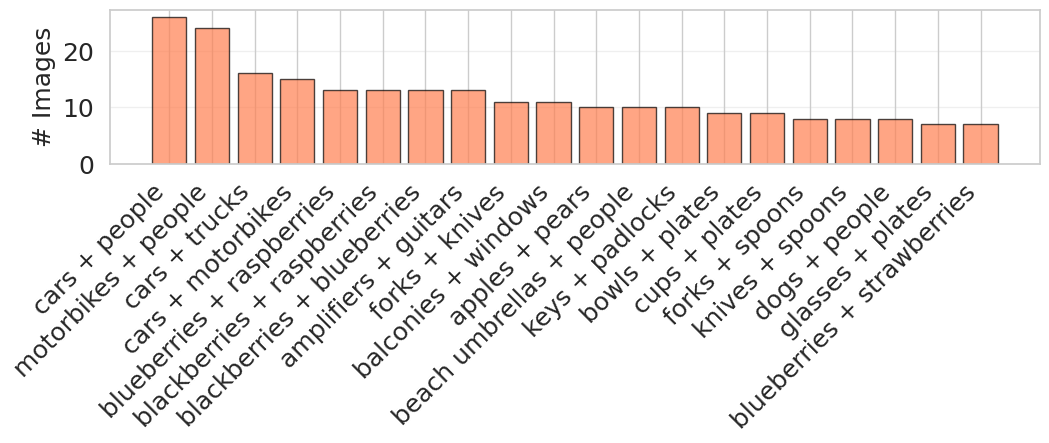

Saved figure: stats/top_cooccurrence_pairs.pdf


In [18]:
# Vertical bar plot for top co-occurring class pairs
top_cooccur_limit = 20  # Parametric limit
top_cooccur_pairs = sorted(class_pairs.items(), key=lambda x: x[1], reverse=True)[:top_cooccur_limit]

# Create labels for pairs
pair_labels = [f"{cls1} + {cls2}" for (cls1, cls2), count in top_cooccur_pairs]
pair_counts = [count for (cls1, cls2), count in top_cooccur_pairs]

fig, ax = plt.subplots(figsize=(12, 2))
bars = ax.bar(range(len(pair_labels)), pair_counts, 
              edgecolor='black', alpha=0.7, color='coral')
ax.set_xticks(range(len(pair_labels)))
ax.set_xticklabels(pair_labels, rotation=45, ha='right', fontsize=18)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=18)
ax.set_ylabel('# Images', fontsize=18)
#ax.set_xlabel('Class Pair', fontsize=15)
#ax.set_title(f'Top {top_cooccur_limit} Class Co-occurrence Pairs', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('stats/top_cooccurrence_pairs.pdf', dpi=400, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/top_cooccurrence_pairs.pdf")

## Top Co-occurrence Pairs (Horizontal Plot)


Cluster-ability metric: Ratio of inter-class centroid distance to average intra-class distance
Higher values indicate better spatial clustering and separability between classes


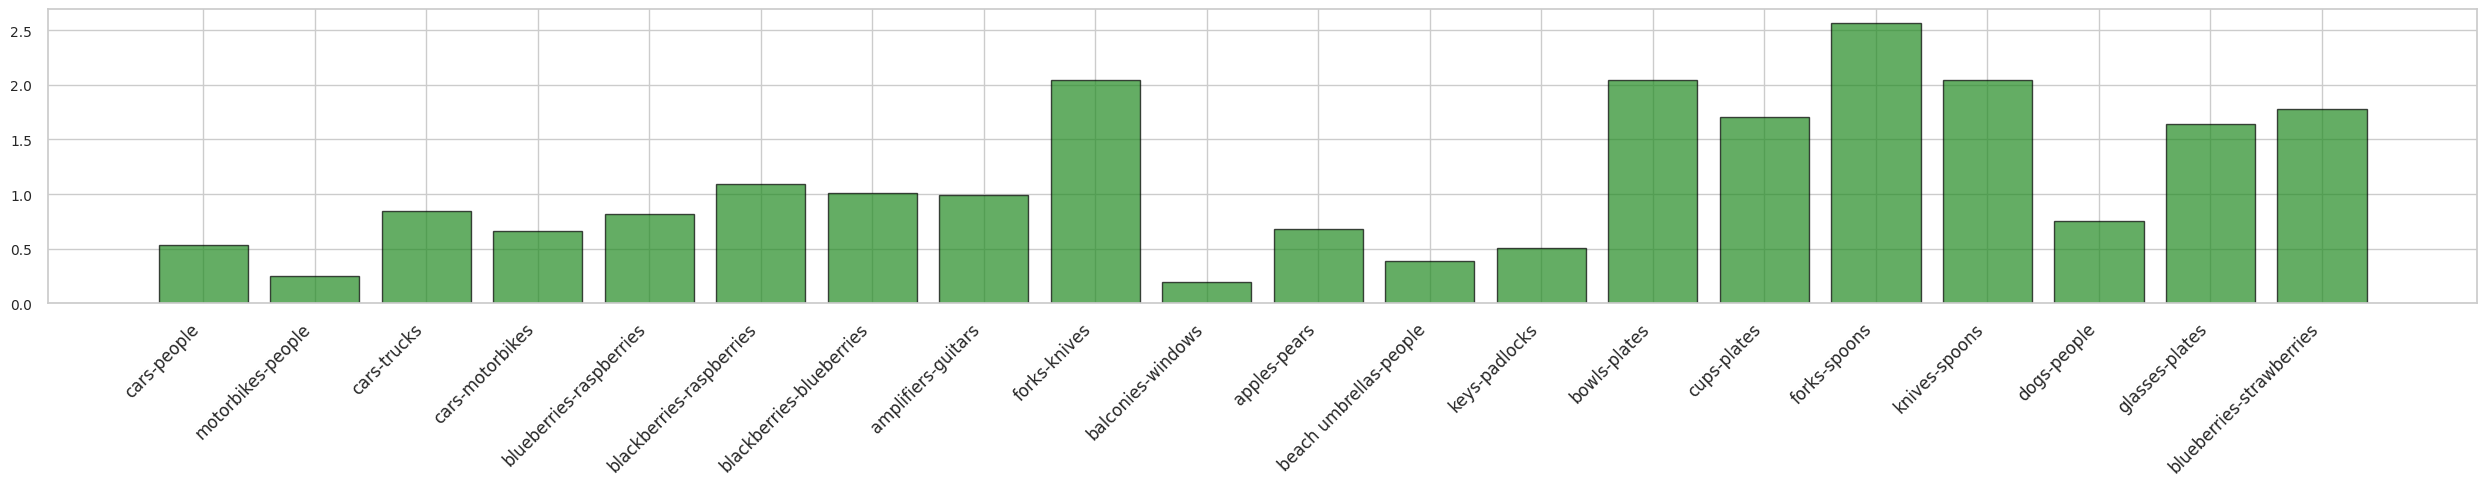

Saved figure: stats/cooccurrence_separability.pdf

Separability metric: Average distance from each point to nearest point of co-occurring class
Higher values indicate better spatial separation between classes


In [19]:
# Calculate cluster-ability for top co-occurring class pairs
# Cluster-ability measures how well the two classes form distinct spatial clusters
# Higher values indicate better separability (distinct clusters)

from scipy.spatial.distance import cdist

# Build mapping from class index to class name
idx_to_class = {int(k): v for k, v in class_mapping.items()}

# Calculate separability for each co-occurring pair
pair_separability = {}

for (cls1, cls2), cooccur_count in top_cooccur_pairs:
    cluster_scores = []
    
    # Go through all images where both classes appear
    for img_name, class_counts in class_counts_per_image.items():
        if class_counts.get(cls1, 0) > 0 and class_counts.get(cls2, 0) > 0:
            # Get point annotations for this image
            if img_name in annotations and 'points' in annotations[img_name] and 'classes' in annotations[img_name]:
                points = np.array(annotations[img_name]['points'])
                class_labels = annotations[img_name]['classes']
                
                # Separate points by class
                points_cls1 = []
                points_cls2 = []
                
                for point, cls_idx in zip(points, class_labels):
                    class_name = idx_to_class.get(cls_idx)
                    if class_name == cls1:
                        points_cls1.append(point)
                    elif class_name == cls2:
                        points_cls2.append(point)
                
                # Calculate cluster-ability if both classes have sufficient points
                if len(points_cls1) >= 2 and len(points_cls2) >= 2:
                    pts1 = np.array(points_cls1)
                    pts2 = np.array(points_cls2)
                    
                    # Calculate intra-class compactness (average distance within each class)
                    intra_dist_cls1 = cdist(pts1, pts1, metric='euclidean')
                    avg_intra_cls1 = intra_dist_cls1[np.triu_indices_from(intra_dist_cls1, k=1)].mean()
                    
                    intra_dist_cls2 = cdist(pts2, pts2, metric='euclidean')
                    avg_intra_cls2 = intra_dist_cls2[np.triu_indices_from(intra_dist_cls2, k=1)].mean()
                    
                    avg_intra = (avg_intra_cls1 + avg_intra_cls2) / 2
                    
                    # Calculate inter-class separation (distance between class centroids)
                    centroid_cls1 = pts1.mean(axis=0)
                    centroid_cls2 = pts2.mean(axis=0)
                    inter_centroid_dist = np.linalg.norm(centroid_cls1 - centroid_cls2)
                    
                    # Cluster-ability score: ratio of between-cluster to within-cluster distance
                    # Higher values = better separated clusters
                    if avg_intra > 0:
                        cluster_score = inter_centroid_dist / avg_intra
                        cluster_scores.append(cluster_score)
    
    # Average cluster-ability across all images where the pair co-occurs
    if cluster_scores:
        pair_separability[(cls1, cls2)] = np.mean(cluster_scores)
    else:
        pair_separability[(cls1, cls2)] = 0

# Create plot
ax.set_ylabel('Cluster-ability Score', fontsize=12)
separability_values = [pair_separability.get((cls1, cls2), 0) for (cls1, cls2), count in top_cooccur_pairs]
pair_labels_sep = [f"{cls1}-{cls2}" for (cls1, cls2), count in top_cooccur_pairs]
fig, ax = plt.subplots(figsize=(25, 5))
bars = ax.bar(range(len(pair_labels_sep)), separability_values, 
              edgecolor='black', alpha=0.7, color='forestgreen')
ax.set_xticks(range(len(pair_labels_sep)))
ax.set_xticklabels(pair_labels_sep, rotation=45, ha='right', fontsize=12)
print(f"\nCluster-ability metric: Ratio of inter-class centroid distance to average intra-class distance")
print(f"Higher values indicate better spatial clustering and separability between classes")

plt.tight_layout()
plt.savefig('stats/cooccurrence_separability.pdf', dpi=400, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/cooccurrence_separability.pdf")
print(f"\nSeparability metric: Average distance from each point to nearest point of co-occurring class")
print(f"Higher values indicate better spatial separation between classes")

## Class Co-occurrence Separability Analysis

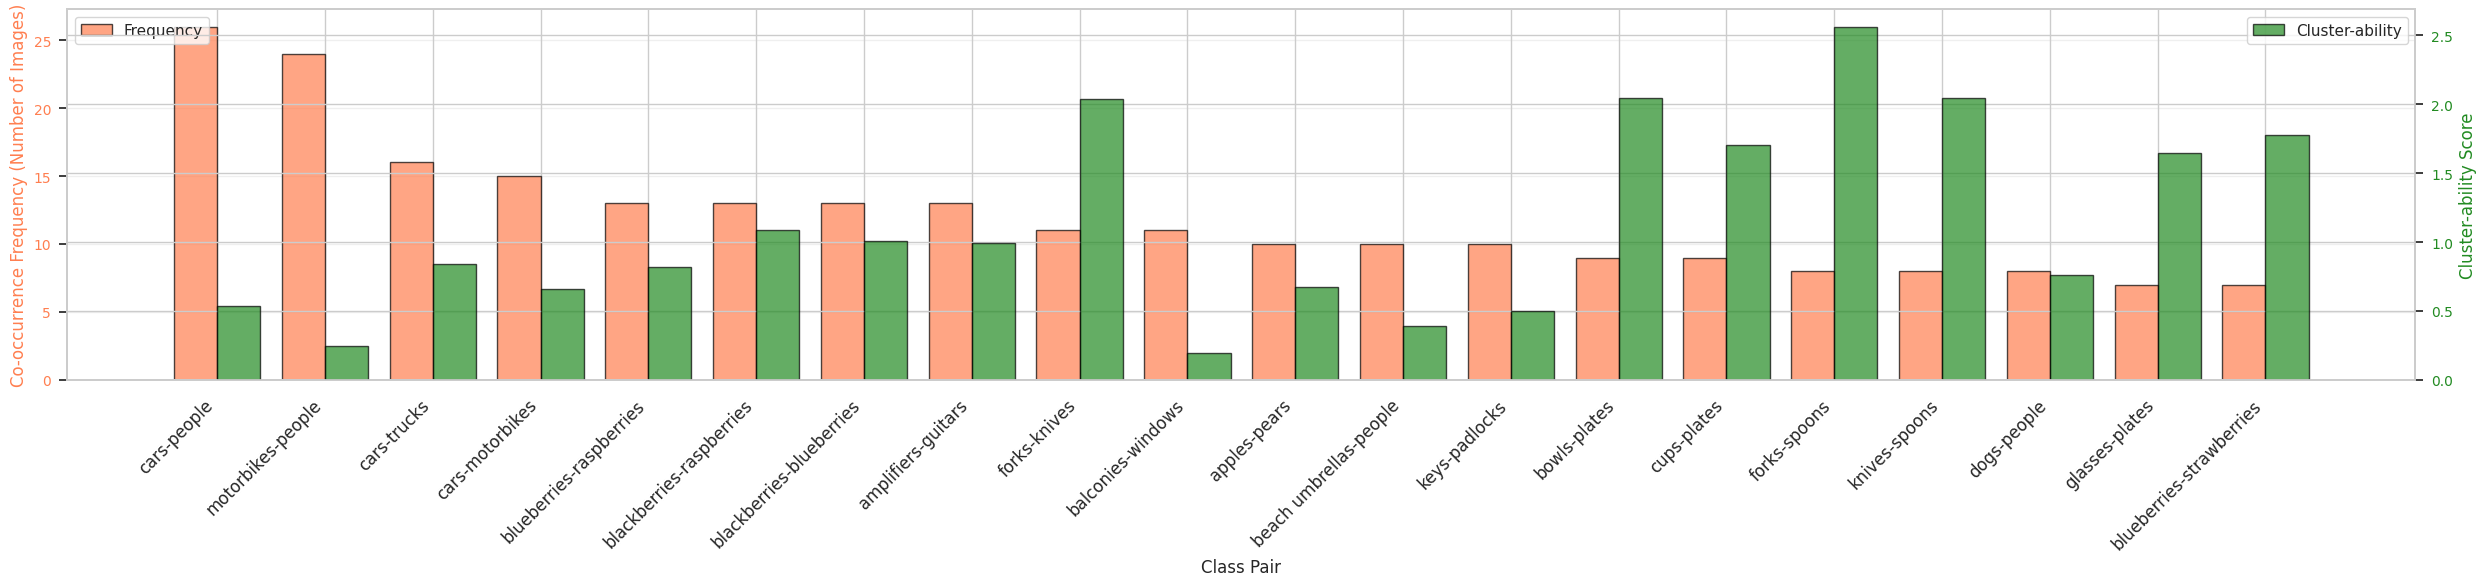

Saved figure: stats/cooccurrence_frequency_vs_separability.pdf

This plot shows the relationship between how often class pairs co-occur
and how well they form distinct spatial clusters (cluster-ability).


In [20]:
# Dual-axis plot showing both frequency and separability of co-occurring pairs
fig, ax1 = plt.subplots(figsize=(25, 6))

# X-axis positions
x_pos = np.arange(len(pair_labels_sep))

# Left y-axis: Frequency (co-occurrence count)
color_freq = 'coral'
ax1.set_xlabel('Class Pair', fontsize=12)
ax1.set_ylabel('Co-occurrence Frequency (Number of Images)', fontsize=12, color=color_freq)
bars1 = ax1.bar(x_pos - 0.2, pair_counts, width=0.4, 
                edgecolor='black', alpha=0.7, color=color_freq, label='Frequency')
ax1.tick_params(axis='y', labelcolor=color_freq)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(pair_labels_sep, rotation=45, ha='right', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# Right y-axis: Cluster-ability
ax2 = ax1.twinx()
color_sep = 'forestgreen'
ax2.set_ylabel('Cluster-ability Score', fontsize=12, color=color_sep)
bars2 = ax2.bar(x_pos + 0.2, separability_values, width=0.4,
                edgecolor='black', alpha=0.7, color=color_sep, label='Cluster-ability')
ax2.tick_params(axis='y', labelcolor=color_sep)

# Add legends
ax1.legend(loc='upper left', fontsize=11)
ax2.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('stats/cooccurrence_frequency_vs_separability.pdf', dpi=400, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/cooccurrence_frequency_vs_separability.pdf")
print(f"\nThis plot shows the relationship between how often class pairs co-occur")
print(f"and how well they form distinct spatial clusters (cluster-ability).")

## Co-occurrence Frequency vs Separability (Dual-Axis Plot)

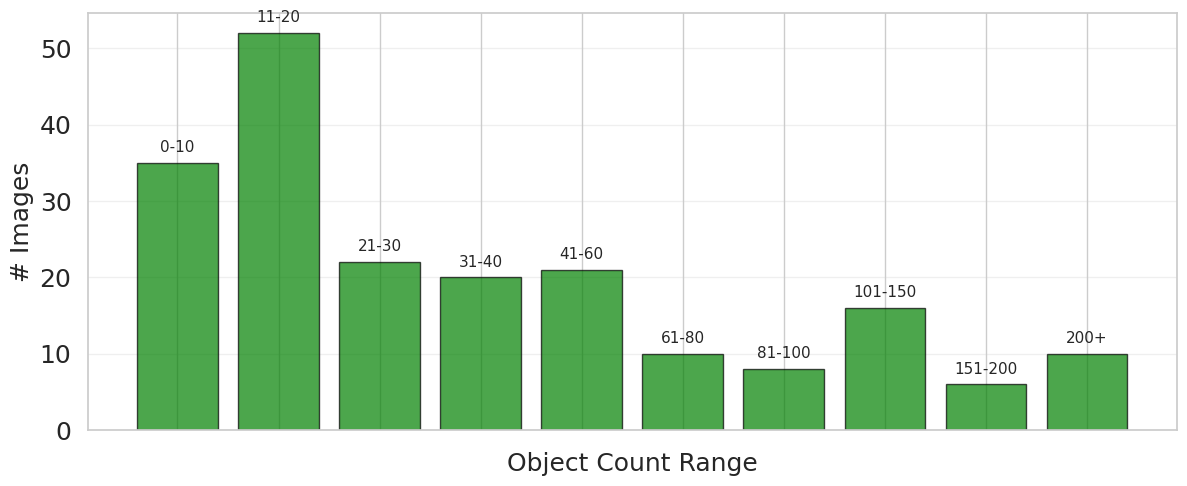

Saved figure: stats/object_count_bins.pdf

Distribution of images across object count bins:
  0-10 objects: 35 images (17.5%)
  11-20 objects: 52 images (26.0%)
  21-30 objects: 22 images (11.0%)
  31-40 objects: 20 images (10.0%)
  41-60 objects: 21 images (10.5%)
  61-80 objects: 10 images (5.0%)
  81-100 objects: 8 images (4.0%)
  101-150 objects: 16 images (8.0%)
  151-200 objects: 6 images (3.0%)
  200+ objects: 10 images (5.0%)


In [26]:
# Horizontal bar plot showing distribution of images across object count bins
counts = list(gt_counts.values())

# Define bins for object counts
bin_edges = [0, 10, 20, 30, 40, 60, 80, 100, 150, 200, max(counts)+1]
bin_labels = ['0-10', '11-20', '21-30', '31-40', '41-60', '61-80', '81-100', '101-150', '151-200', '200+']

# Count images in each bin
bin_counts = []
for i in range(len(bin_edges)-1):
    count = sum(1 for c in counts if bin_edges[i] < c <= bin_edges[i+1])
    bin_counts.append(count)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(bin_labels)), bin_counts, 
              edgecolor='black', alpha=0.7, color='green')
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels([''] * len(bin_labels))
ax.tick_params(axis='y', labelsize=18)
ax.set_ylabel('# Images', fontsize=18)
ax.set_xlabel('Object Count Range', fontsize=18)
ax.grid(True, alpha=0.3, axis='y')

# Show bin labels above bars instead of below the x-axis
y_offset = max(bin_counts) * 0.02
for bar, label in zip(bars, bin_labels):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height() + y_offset
    ax.text(x, y, label, ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('stats/object_count_bins.pdf', dpi=400, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/object_count_bins.pdf")
print(f"\nDistribution of images across object count bins:")
for label, count in zip(bin_labels, bin_counts):
    percentage = (count / total_images) * 100
    print(f"  {label} objects: {count} images ({percentage:.1f}%)")

## Object Count Distribution by Bins

/tmp/ipykernel_3206437/257047975.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=18)


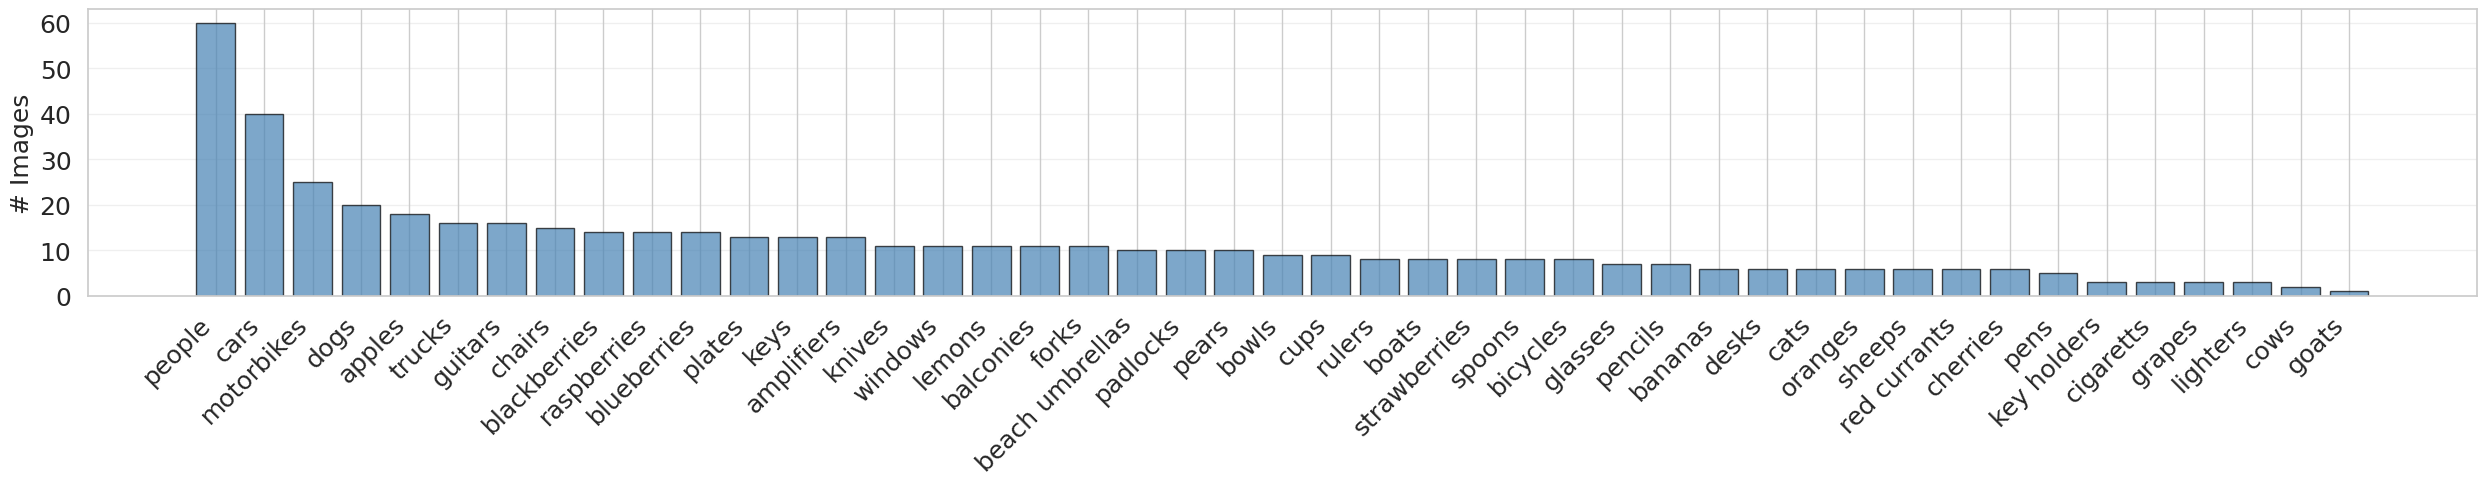

Saved figure: stats/all_classes_by_image_frequency.pdf


In [22]:
# Vertical bar plot for all classes showing number of images containing each class
df_all_classes = df_class_stats.sort_values('Num Images', ascending=False)  # descending order

fig, ax = plt.subplots(figsize=(25, 5))
bars = ax.bar(range(len(df_all_classes)), df_all_classes['Num Images'], 
              edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xticks(range(len(df_all_classes)))
ax.set_xticklabels(df_all_classes['Class'], rotation=45, ha='right', fontsize=18)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=18)
ax.set_ylabel('# Images', fontsize=18)
#ax.set_xlabel('Class Name', fontsize=15)
#ax.set_title(f'All {len(df_all_classes)} Classes by Image Frequency', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('stats/all_classes_by_image_frequency.pdf', dpi=400, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/all_classes_by_image_frequency.pdf")

## All Classes by Image Frequency (Horizontal Plot)

## Final Summary

All statistics have been computed and visualizations generated. All output files are saved in the `stats/` folder:

### CSV Files (in stats/):
- `dataset_summary_statistics.csv` - Overall dataset statistics
- `class_statistics.csv` - Detailed per-class statistics

### Figures (in stats/, all in PDF format):
- `dataset_stats_4panel.pdf` - **Publication-quality 4-panel summary figure**
  - Panel (a): Object count distribution with histogram
  - Panel (b): Top 15 class frequencies
  - Panel (c): Class co-occurrence matrix (top 5 classes)
  - Panel (d): Clutter vs. density analysis using nearest neighbor distances
- `all_classes_by_image_frequency.pdf` - Horizontal bar plot of all 46 classes by image frequency
- `top_cooccurrence_pairs.pdf` - Horizontal bar plot of top 45 co-occurrence pairs by frequency
- `cooccurrence_separability.pdf` - Cluster-ability analysis of co-occurring class pairs
- `cooccurrence_frequency_vs_separability.pdf` - Dual-axis plot showing frequency and cluster-ability
- `object_count_bins.pdf` - Distribution of images across object count bins
- `object_distribution.pdf` - Distribution of objects per image
- `classes_per_image_distribution.pdf` - Distribution of classes per image
- `top_classes_by_instances.pdf` - Top classes by total instances
- `top_classes_by_frequency.pdf` - Most frequent classes across images
- `top_classes_by_avg_count.pdf` - Classes with highest average count
- `difficulty_distribution.pdf` - Images by counting difficulty
- `resolution_analysis.pdf` - Image resolution and aspect ratio analysis

### LaTeX (in stats/):
- `dataset_statistics_latex.tex` - LaTeX table for paper inclusion

These comprehensive statistics and visualizations are paper-ready and organized for easy integration into your benchmark publication!

/tmp/ipykernel_3206437/2749290646.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=18)


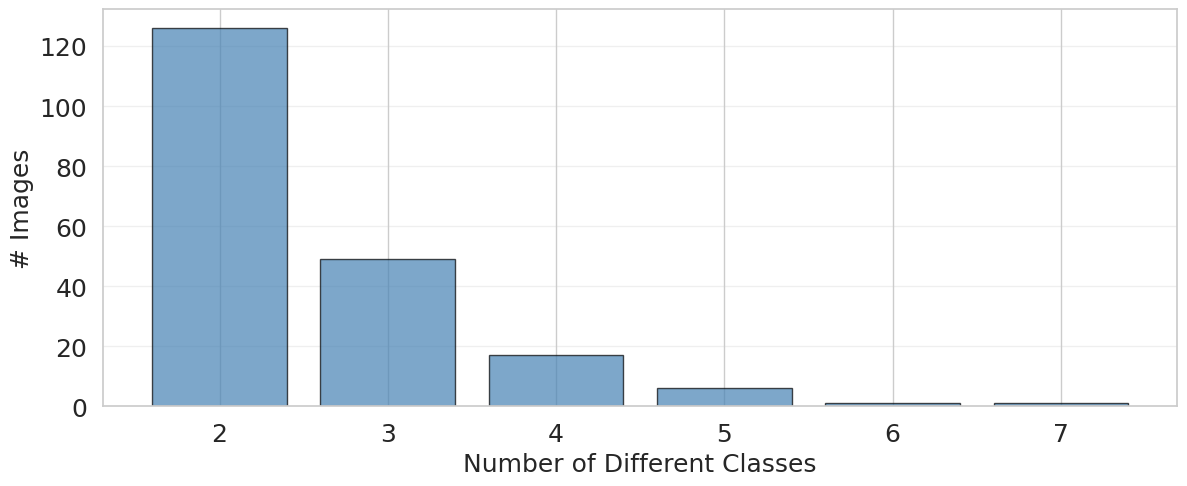

Saved figure: stats/class_count_bins.pdf

Distribution of images across number of different classes:
  2 different classes: 126 images (63.0%)
  3 different classes: 49 images (24.5%)
  4 different classes: 17 images (8.5%)
  5 different classes: 6 images (3.0%)
  6 different classes: 1 images (0.5%)
  7 different classes: 1 images (0.5%)


In [23]:
# Vertical bar plot showing distribution of images across number of classes
# Sort by number of classes
classes_dist_sorted = sorted(classes_distribution.items())
class_nums = [x[0] for x in classes_dist_sorted]
class_img_counts = [x[1] for x in classes_dist_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(class_nums)), class_img_counts, 
              edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xticks(range(len(class_nums)))
ax.set_xticklabels(class_nums, fontsize=18)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=18)
ax.set_ylabel('# Images', fontsize=18)
ax.set_xlabel('Number of Different Classes', fontsize=18)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('stats/class_count_bins.pdf', dpi=400, bbox_inches='tight')
plt.show()

print(f"Saved figure: stats/class_count_bins.pdf")
print(f"\nDistribution of images across number of different classes:")
for num_classes, count in classes_dist_sorted:
    percentage = (count / total_images) * 100
    print(f"  {num_classes} different classes: {count} images ({percentage:.1f}%)")